In [1]:
from biological_fuzzy_logic_networks.DREAM.DREAMBioFuzzNet import DREAMBioFuzzNet
from biological_fuzzy_logic_networks.DREAM_analysis.utils import (
    prepare_cell_line_data,
    cl_data_to_input,
)

from sklearn.metrics import r2_score

import torch
import json
import pickle

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/dccstor/ipc1/.conda/envs/biofuzznet2/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


In [2]:
pkn_sif = "/dccstor/ipc1/CAR/DREAM/DREAMdata/Alice_subnetwork.sif"

In [3]:
ckpt_path = "/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/"

In [4]:
ckpt = torch.load(f"{ckpt_path}/model.pt", map_location=torch.device("cpu"))
model = DREAMBioFuzzNet.build_DREAMBioFuzzNet_from_file(pkn_sif)
model.load_from_checkpoint(ckpt["model_state_dict"])

with open(f"{ckpt_path}scaler.pkl", "rb") as f:
        scaler = pickle.load(f)

In [5]:
model

In [6]:
with open("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/Configs/HCC70_config.json") as f:
    config = json.load(f)
f.close()
config

{'pkn_sif': '/dccstor/ipc1/CAR/DREAM/DREAMdata/Alice_subnetwork.sif',
 'network_class': 'DREAMBioFuzzNet',
 'data_file': '/dccstor/ipc1/CAR/DREAM/DREAMdata/Time_aligned_per_cell_line/CL_incl_test/HCC70.csv',
 'output_dir': '/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/',
 'time_point': 9,
 'non_marker_cols': ['treatment', 'cell_line', 'time'],
 'treatment_col_name': 'treatment',
 'sel_condition': 'EGF',
 'sample_n_cells': False,
 'filter_starved_stim': True,
 'add_root_values': True,
 'root_nodes': ['EGFR'],
 'input_value': 1,
 'train_treatments': None,
 'valid_treatments': None,
 'train_cell_lines': None,
 'valid_cell_lines': None,
 'convergence_check': False,
 'replace_zero_inputs': 1e-09,
 'inhibition_value': 1.0,
 'learning_rate': 0.001,
 'n_epochs': 800,
 'batch_size': 500,
 'checkpoint_path': '/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/',
 'experiment_name': 'OneCellLine',
 'optimizer': 'SGD',
 'scale_type': 'minmax',
 'patience': 20,
 'cell_lines': 'HCC

In [7]:
cl_data = prepare_cell_line_data(
    data_file=config["data_file"],
    time_point=config["time_point"],
    non_marker_cols=config["non_marker_cols"],
    treatment_col_name=config["treatment_col_name"],
    filter_starved_stim=config["filter_starved_stim"],
    sample_n_cells=config["sample_n_cells"],
    sel_condition="iMEK",
)

# Load train and valid data
(   train_data,
    valid_data,
    train_inhibitors,
    valid_inhibitors,
    train_input,
    valid_input,
    train,
    valid,
 scaler
) = cl_data_to_input(
    data=cl_data,
    model=model,
    train_treatments=None,
    valid_treatments=None,
    train_cell_lines=None,
    valid_cell_lines=None,
    inhibition_value=1.5,
    add_root_values=config["add_root_values"],
    input_value=config["input_value"],
    root_nodes=config["root_nodes"],
    replace_zero_inputs=config["replace_zero_inputs"],
    balance_data=True,
    scaler=scaler
)

<class 'str'>
['HCC70']
Scaler provided, ignoring `scale type`


/u/adr/Code/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:289: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/u/adr/Code/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:289: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[t < 0] = 1e-9
/u/adr/Code/biological_fuzzy_logic_networks/biological_fuzzy_logic_networks/DREAM_analysis/utils.py:290: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [8]:
with torch.no_grad():
    model.initialise_random_truth_and_output(len(valid))
    model.set_network_ground_truth(valid_data)
    model.sequential_update(model.root_nodes, valid_inhibitors)
    val_output_states = pd.DataFrame(
        {k: v.cpu().numpy() for k, v in model.output_states.items()}
    )



In [9]:
node_r2_scores = {}
for node in valid_data.keys():
    node_r2_scores[f"val_r2_{node}"] = r2_score(
        valid[node], val_output_states[node]
    )

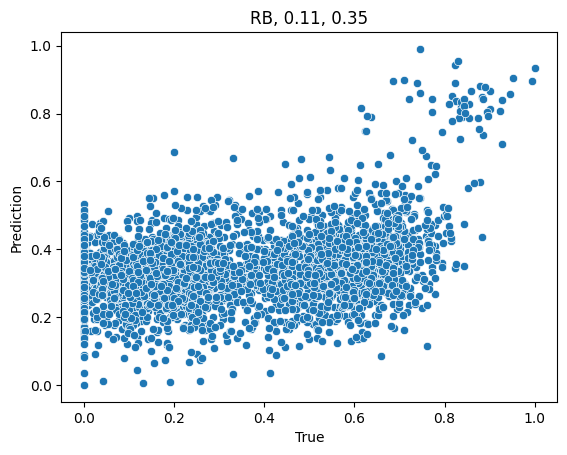

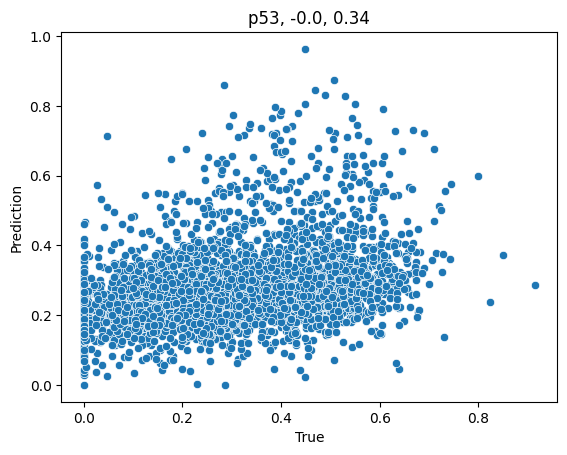

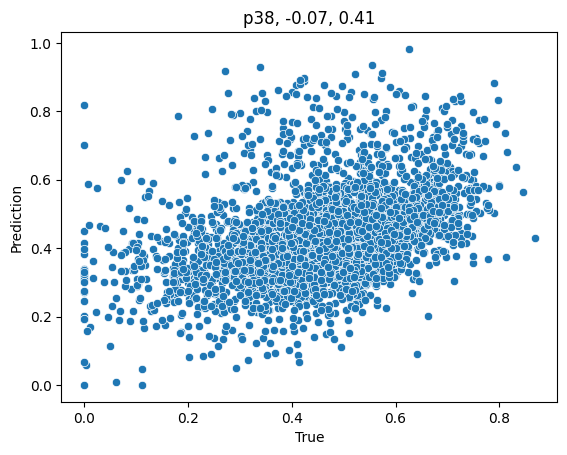

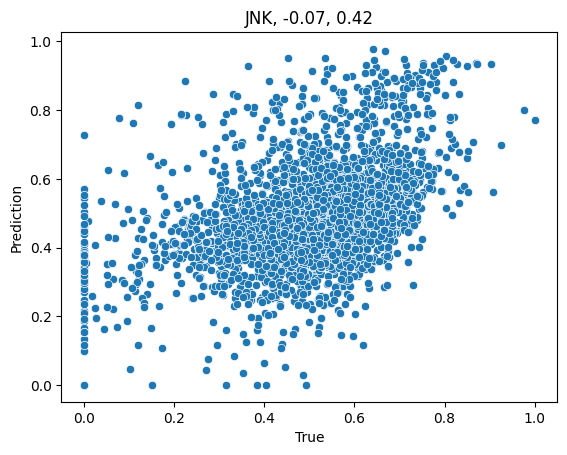

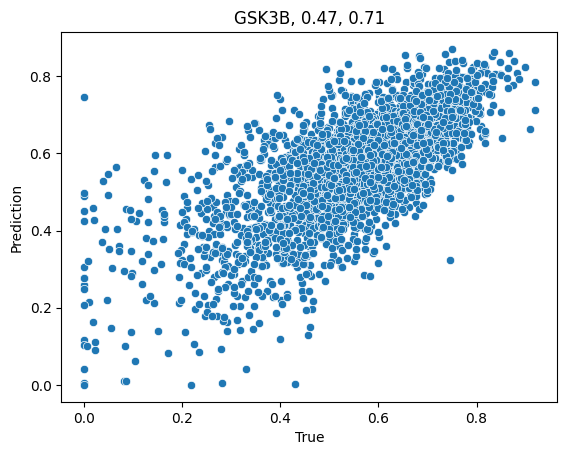

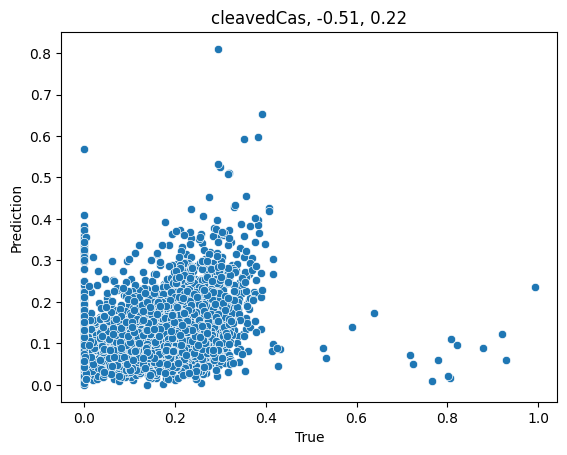

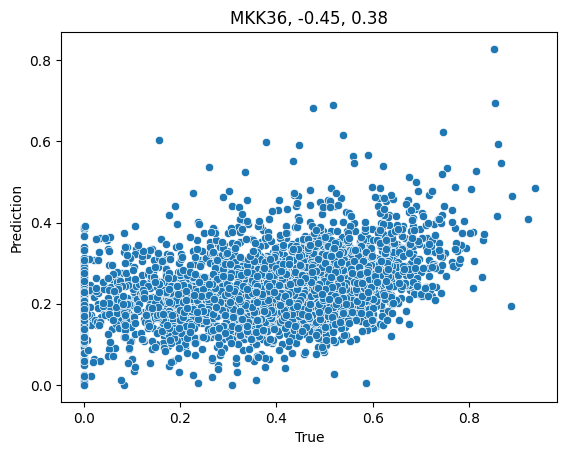

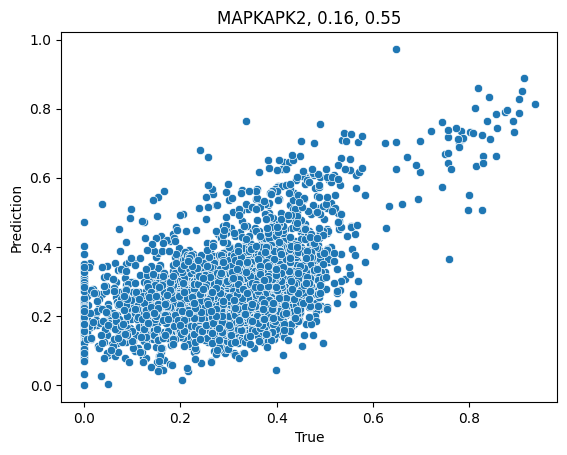

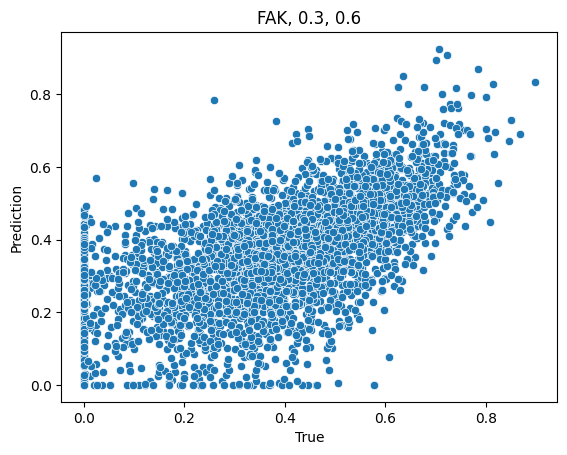

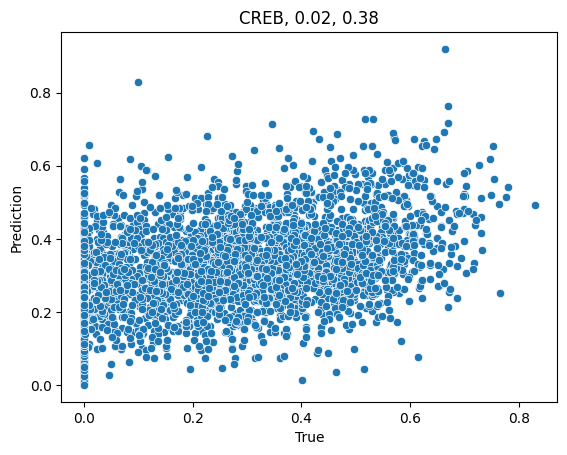

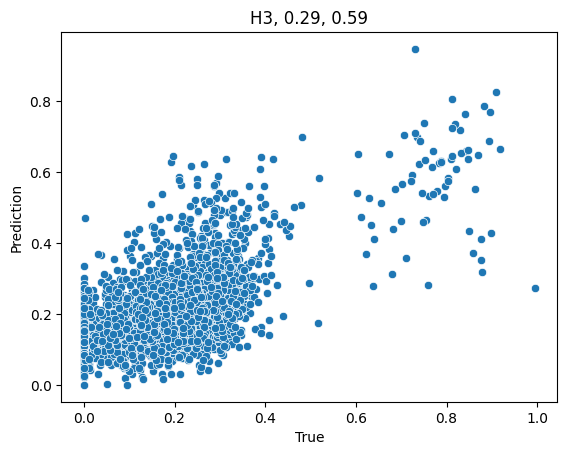

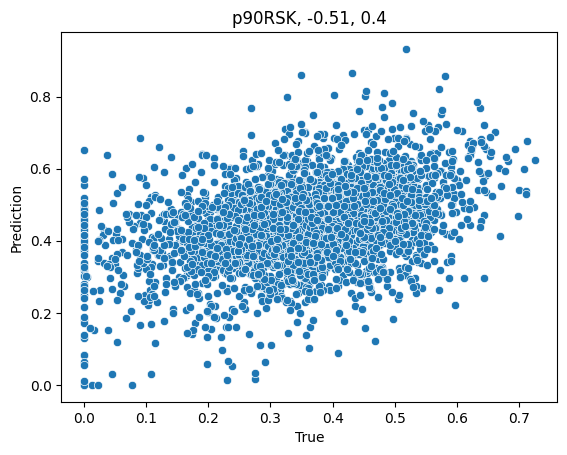

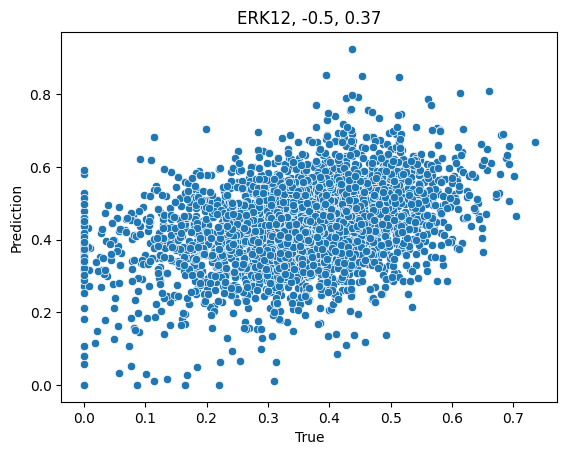

In [10]:
eval_markers = ["RB", "p53", "p38", "JNK", "GSK3B", "cleavedCas", "MKK36", "MAPKAPK2", 
                "FAK", "CREB", "H3", "p90RSK", "ERK12"]
valid=valid.reset_index(drop=True)
r2_scores = []
correlations = []
for marker in eval_markers:
    corr = valid[marker].corr(val_output_states[marker], method='pearson')
    correlations.append(corr)
    r2 = r2_score(valid[marker], val_output_states[marker])
    r2_scores.append(r2)
    sns.scatterplot(x=valid[marker], y=val_output_states[marker])
    plt.xlabel("True")
    plt.ylabel("Prediction")
    plt.title(f"{marker}, {round(r2, 2)}, {round(corr, 2)}")
    plt.show()

In [11]:
# valid.to_csv(f"{ckpt_path}/valid_iMEK.csv")